EDA

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

df = pd.read_csv('cleaned_data.csv')
df_eda = df.copy()
print("Shape:", df.shape)
df.head()

Shape: (912, 33)


,Date,Month,Ward,Location,Road_Type,No_of_vehicles_involved,Minor_Injury,Severe_Injury,Fatal/Death,Time_Range,Cause,Month_Num,Nepali_Season,Season,Weather_Clear,Weather_Cold,Weather_Cool,Weather_Dry,Weather_Dusty,Weather_Foggy,Weather_Frosty,Weather_Hot,Weather_Humid,Weather_Mild,Weather_Overcast,Weather_Pleasant,Weather_Rainy,Weather_Thunderstorm,Weather_Warm,Weather_Windy,Severity,Total_Injuries,Casualties
0,2081-04-02 00:00:00,Shrawan,4,oil nigam,highway,2,1,0,0,06:00-12:00,speeding,4,Barkha,Summer,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,low,1,1
1,2081-04-02 00:00:00,Shrawan,12,roadcess chowk,highway,2,4,0,0,06:00-12:00,speeding,4,Barkha,Summer,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,low,4,4
2,2081-04-02 00:00:00,Shrawan,4,rajbanshi chowk,highway,2,0,1,0,12:00-18:00,driver's fault,4,Barkha,Summer,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,high,1,1
3,2081-04-03 00:00:00,Shrawan,18,rani,inner paved road,1,1,0,0,18:00-00:00,drunk and drive,4,Barkha,Summer,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,low,1,1
4,2081-04-05 00:00:00,Shrawan,19,pushpalal chowk,inner paved road,2,1,0,0,12:00-18:00,pedestrian’s fault,4,Barkha,Summer,0,0,0,0,0,1,0,0,1,0,1,0,1,0,0,0,low,1,1


In [2]:
print("=== Data Info ===")
print(df_eda.info())

print("\n=== Missing Values ===")
print(df_eda.isnull().sum())

print("\n=== Severity Distribution ===")
print(df_eda['Severity'].value_counts())

df_eda['Ward_Location'] = 'Ward ' + df_eda['Ward'].astype(str) + ' — ' + df_eda['Location']


=== Data Info ===
<class 'pandas.DataFrame'>
RangeIndex: 912 entries, 0 to 911
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Date                     912 non-null    str  
 1   Month                    912 non-null    str  
 2   Ward                     912 non-null    int64
 3   Location                 912 non-null    str  
 4   Road_Type                912 non-null    str  
 5   No_of_vehicles_involved  912 non-null    int64
 6   Minor_Injury             912 non-null    int64
 7   Severe_Injury            912 non-null    int64
 8   Fatal/Death              912 non-null    int64
 9   Time_Range               912 non-null    str  
 10  Cause                    910 non-null    str  
 11  Month_Num                912 non-null    int64
 12  Nepali_Season            912 non-null    str  
 13  Season                   912 non-null    str  
 14  Weather_Clear            912 non-null    int64
 15 

C:\Users\Acer\AppData\Local\Temp\ipykernel_14372\2922125005.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='Severity', order=order, palette={'low': 'green', 'high': 'red'}, ax=axes[0])


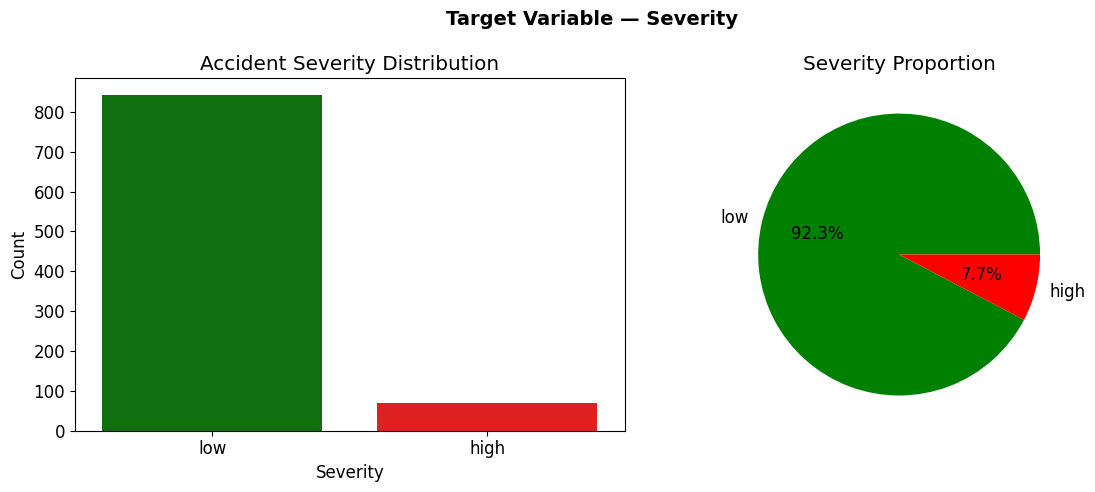

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

order = ['low', 'high']

# Count plot
sns.countplot(data=df_eda, x='Severity', order=order, palette={'low': 'green', 'high': 'red'}, ax=axes[0])
axes[0].set_title('Accident Severity Distribution')
axes[0].set_xlabel('Severity')
axes[0].set_ylabel('Count')

# Pie chart
severity_counts = df_eda['Severity'].value_counts().reindex(order)

axes[1].pie(
    severity_counts,
    labels=severity_counts.index,
    autopct='%1.1f%%',
    colors=['green', 'red']
)
axes[1].set_title('Severity Proportion')

plt.suptitle('Target Variable — Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

C:\Users\Acer\AppData\Local\Temp\ipykernel_14372\773553550.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_eda, x='Time_Range', order=time_order, palette='Blues_d', ax=axes[0])


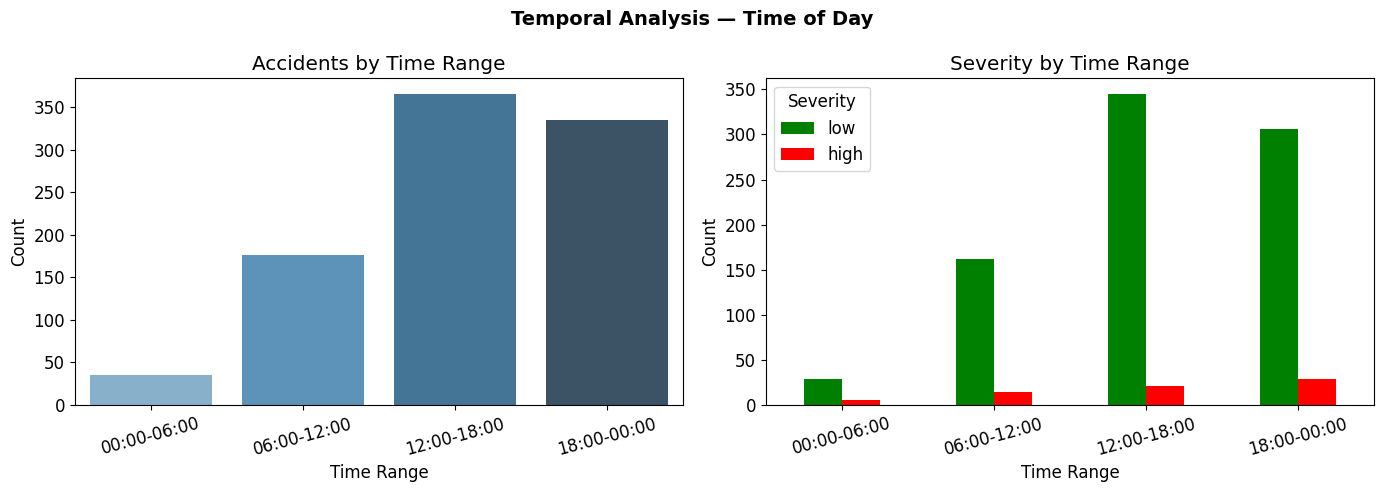

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

time_order = ['00:00-06:00', '06:00-12:00', '12:00-18:00', '18:00-00:00']

# Accidents by time range
sns.countplot(data=df_eda, x='Time_Range', order=time_order, palette='Blues_d', ax=axes[0])
axes[0].set_title('Accidents by Time Range')
axes[0].set_xlabel('Time Range')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# Severity by time range
severity_time = df_eda.groupby(['Time_Range', 'Severity']).size().unstack(fill_value=0)
severity_time = severity_time.reindex(time_order).reindex(
    columns=['low', 'high'],
    fill_value=0
)

severity_time.plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('Severity by Time Range')
axes[1].set_xlabel('Time Range')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Severity')

plt.suptitle('Temporal Analysis — Time of Day', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

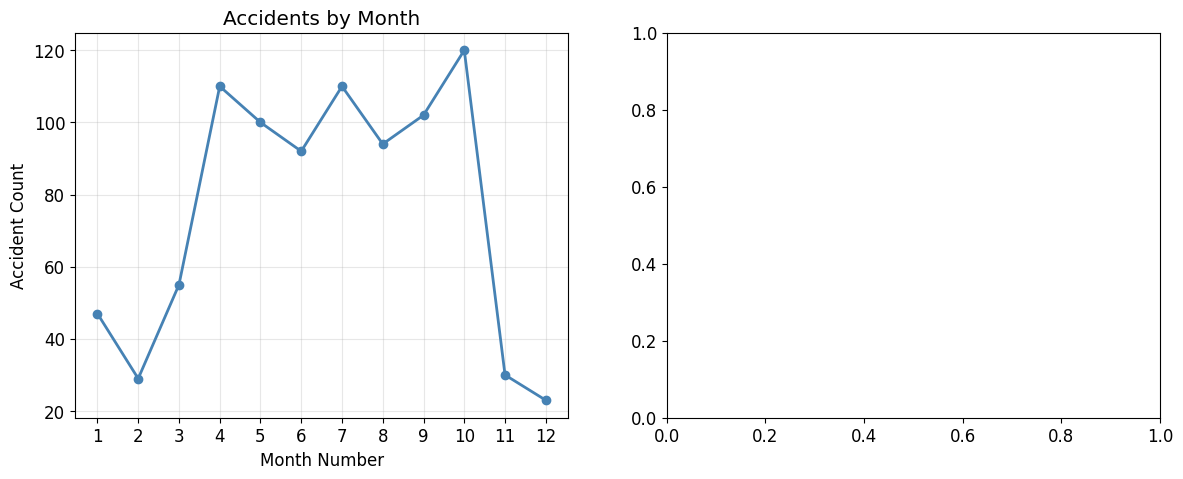

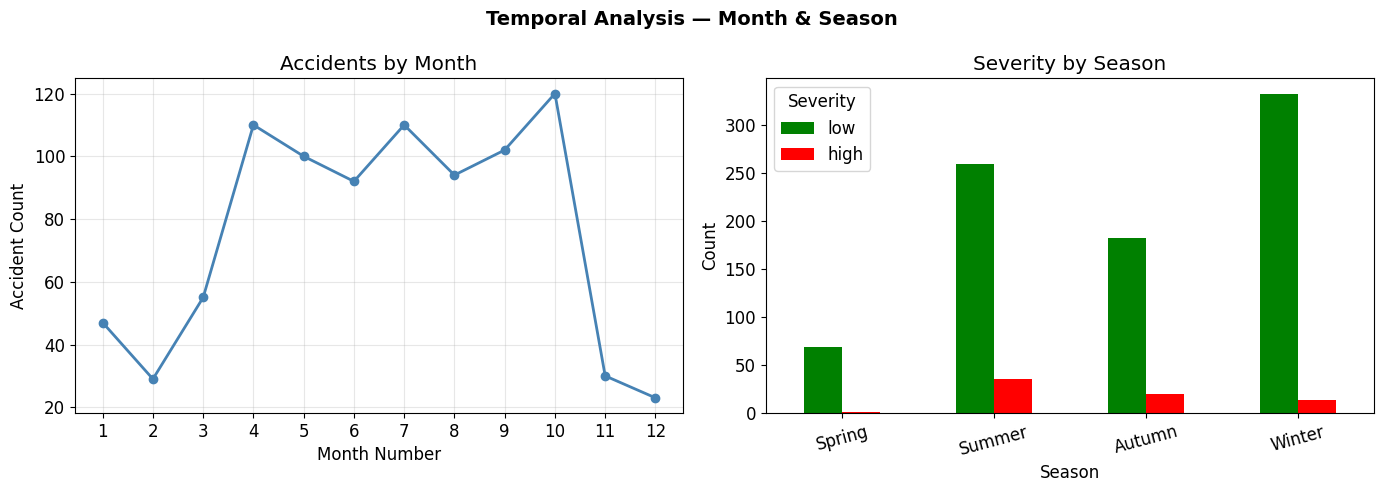

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accidents by month number
monthly = df_eda.groupby('Month_Num').size().reset_index(name='Count')
axes[0].plot(monthly['Month_Num'], monthly['Count'], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Accidents by Month')
axes[0].set_xlabel('Month Number')
axes[0].set_ylabel('Accident Count')
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accidents by month number
monthly = df_eda.groupby('Month_Num').size().reset_index(name='Count')
axes[0].plot(monthly['Month_Num'], monthly['Count'], marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Accidents by Month')
axes[0].set_xlabel('Month Number')
axes[0].set_ylabel('Accident Count')
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, alpha=0.3)

# Severity by Season
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']

severity_season = df_eda.groupby(['Season', 'Severity']).size().unstack(fill_value=0)
severity_season = severity_season.reindex(season_order).reindex(
    columns=['low', 'high'],
    fill_value=0
)

severity_season.plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('Severity by Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Severity')

plt.suptitle('Temporal Analysis — Month & Season', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()




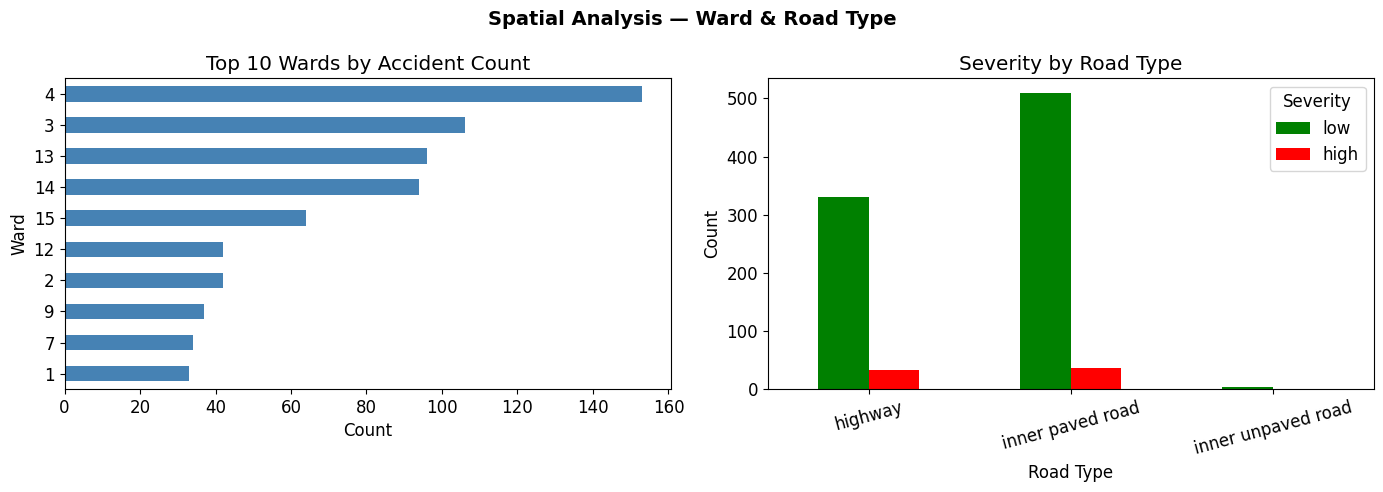

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 wards by accident count
ward_counts = df_eda['Ward'].value_counts().head(10)
ward_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Wards by Accident Count')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('Ward')
axes[0].invert_yaxis()

# Severity by Road Type
road_severity = df_eda.groupby(['Road_Type', 'Severity']).size().unstack(fill_value=0)
road_severity = road_severity.reindex(
    columns=['low', 'high'],
    fill_value=0
)

road_severity.plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('Severity by Road Type')
axes[1].set_xlabel('Road Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Severity')

plt.suptitle('Spatial Analysis — Ward & Road Type', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



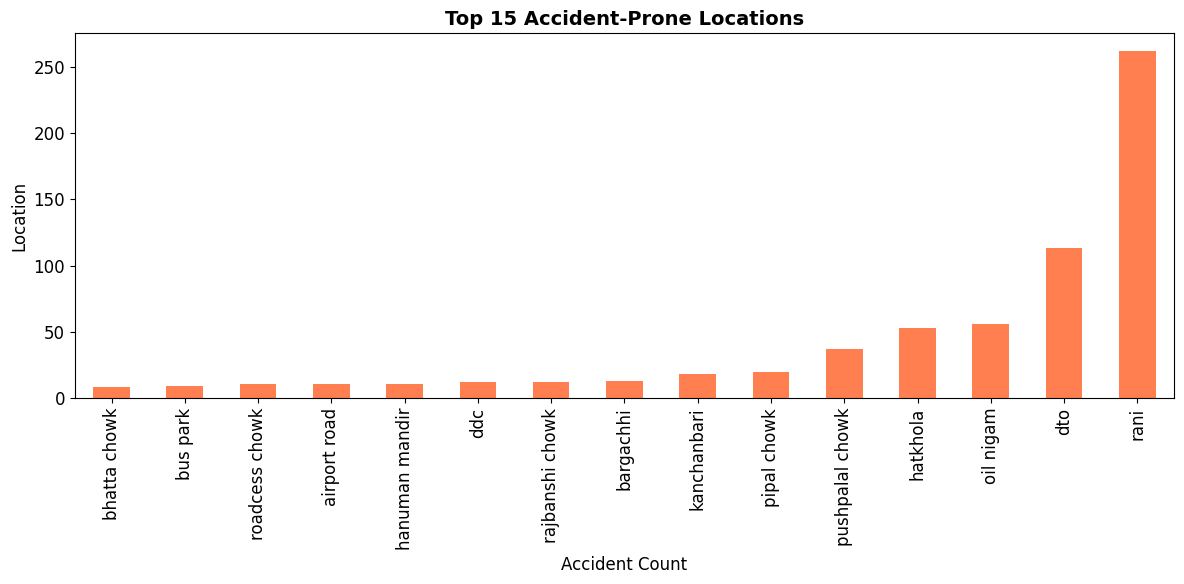

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

top_locations = df_eda['Location'].value_counts().head(15).sort_values()

top_locations.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Top 15 Accident-Prone Locations', fontsize=14, fontweight='bold')
ax.set_xlabel('Accident Count')
ax.set_ylabel('Location')

plt.tight_layout()
plt.show()


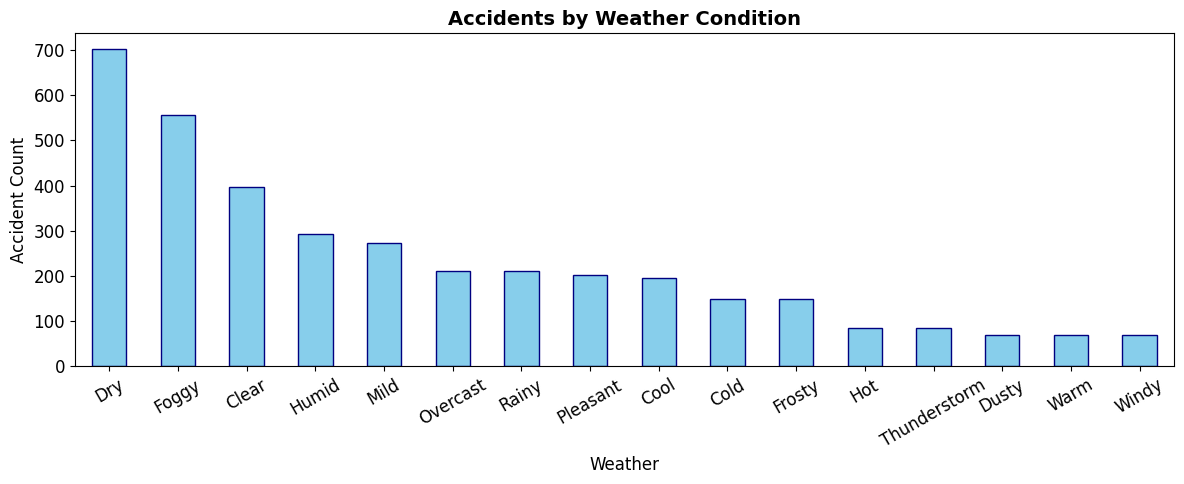

In [8]:
weather_cols = [col for col in df_eda.columns if col.startswith('Weather_')]

# Rename columns first
weather_df = df_eda[weather_cols].copy()
weather_df.columns = [col.replace('Weather_', '') for col in weather_df.columns]

# Sum and sort
weather_totals = weather_df.sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
weather_totals.plot(kind='bar', ax=ax, color='skyblue', edgecolor='navy')

ax.set_title('Accidents by Weather Condition', fontsize=14, fontweight='bold')
ax.set_xlabel('Weather')
ax.set_ylabel('Accident Count')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


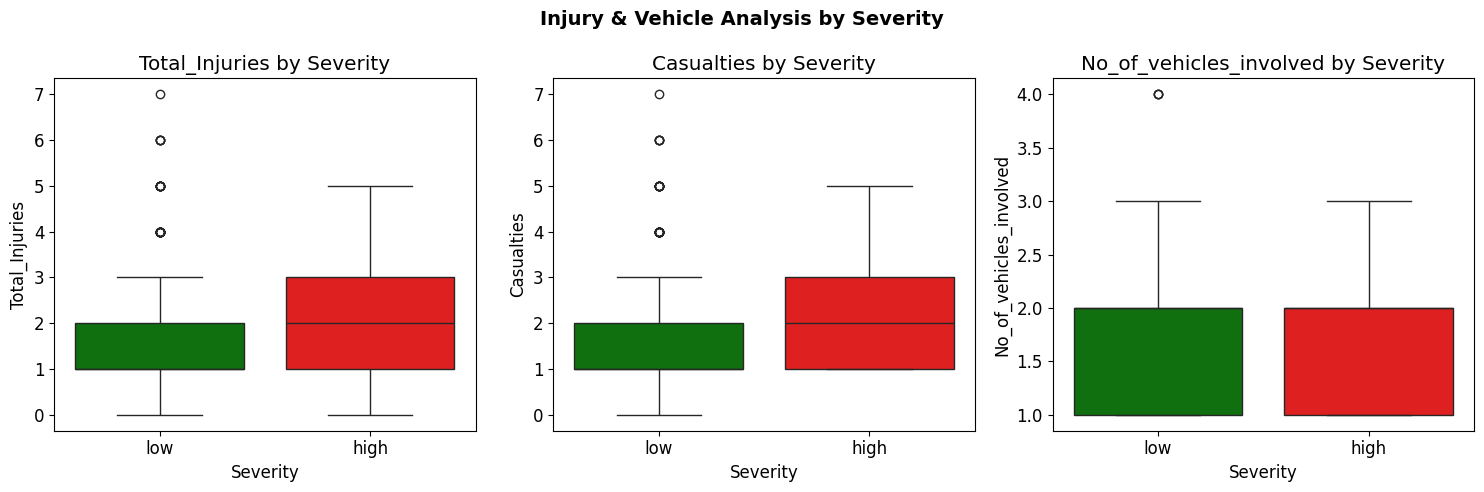

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['Total_Injuries', 'Casualties', 'No_of_vehicles_involved']):
    sns.boxplot(data=df_eda, x='Severity', y=col,
                order=['low', 'high'],
                hue='Severity',
                palette={'low': 'green', 'high': 'red'},
                legend=False,
                ax=ax)
    ax.set_title(f'{col} by Severity')
    ax.set_xlabel('Severity')

plt.suptitle('Injury & Vehicle Analysis by Severity', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Risk Frequency analysis

In [10]:
df_eda['Ward_Location'] = 'Ward ' + df_eda['Ward'].astype(str) + ' — ' + df_eda['Location']

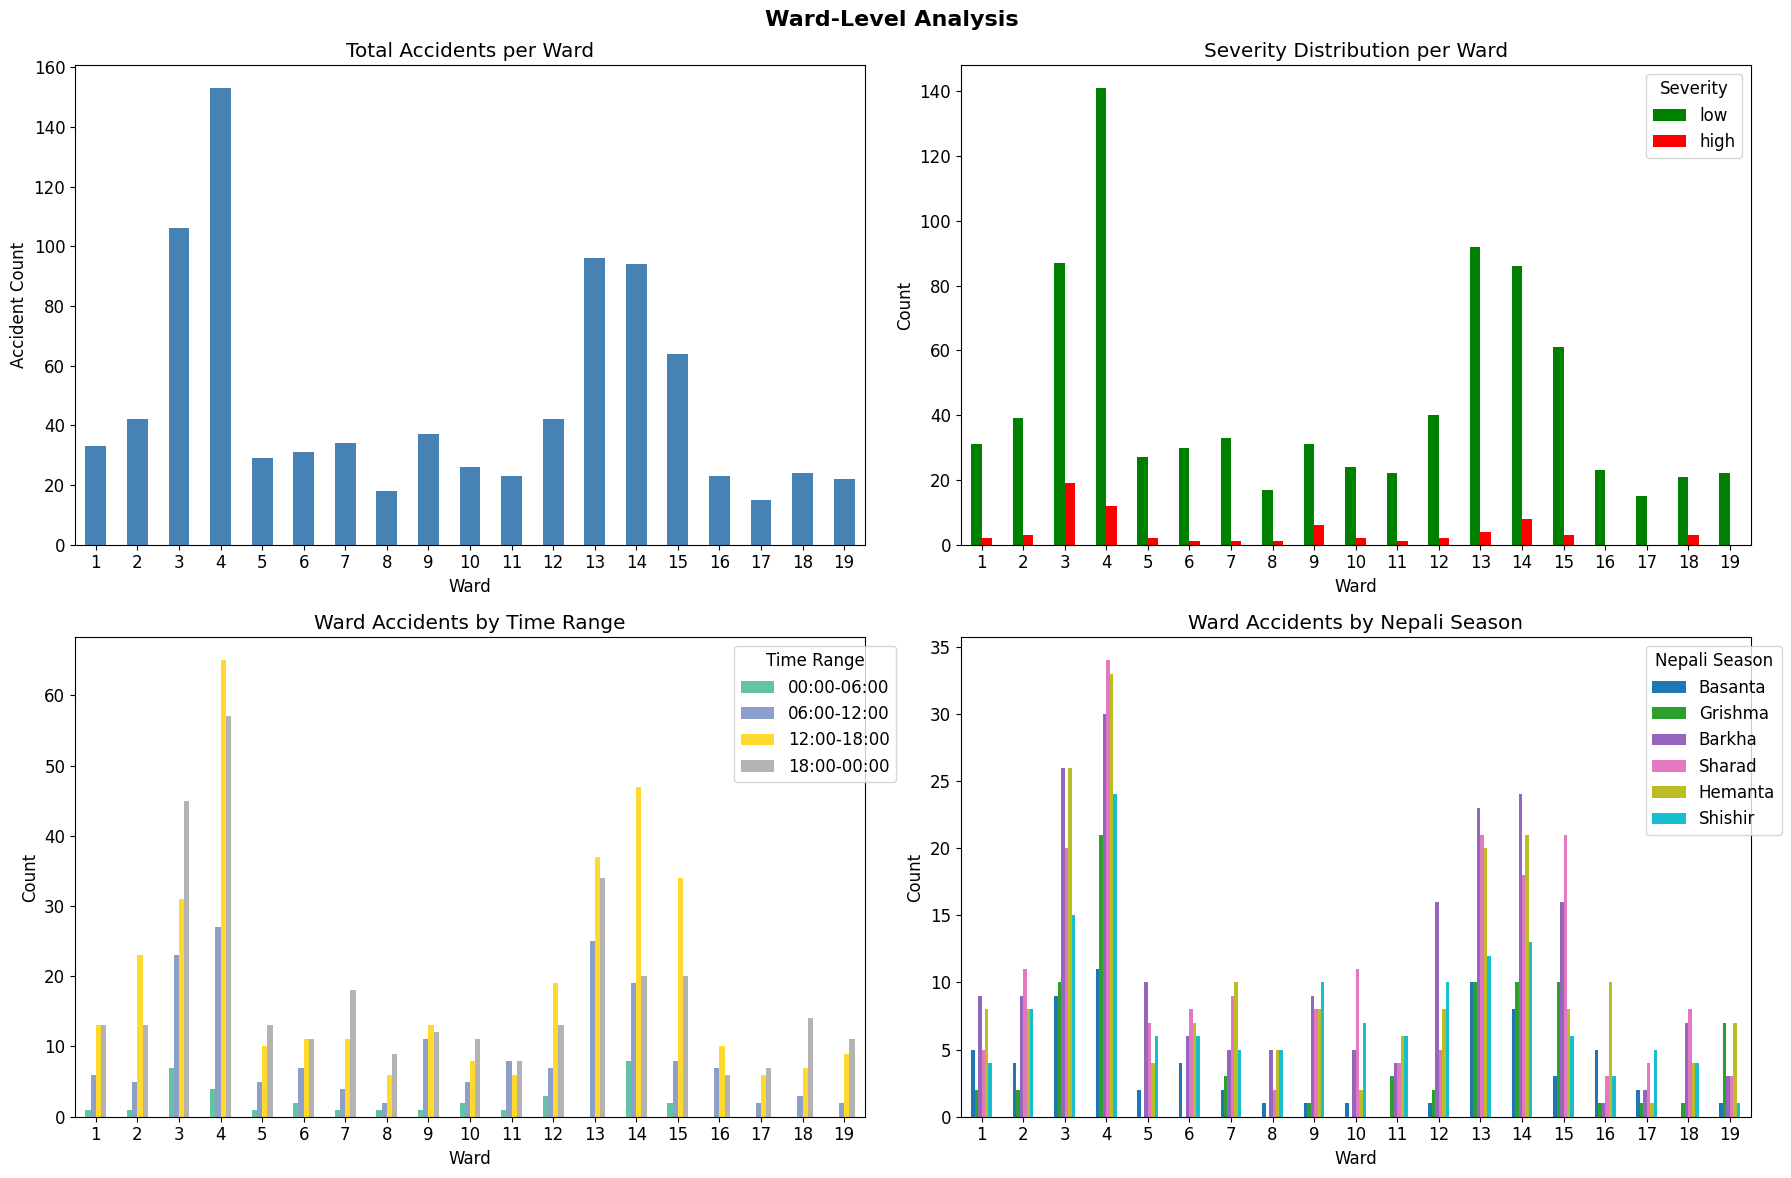

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

time_order = ['00:00-06:00', '06:00-12:00', '12:00-18:00', '18:00-00:00']
nepali_season_order = ['Basanta', 'Grishma', 'Barkha', 'Sharad', 'Hemanta', 'Shishir']

# 11a — Accident count per ward
ward_counts = df_eda['Ward'].value_counts().sort_index()
ward_counts.plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Total Accidents per Ward')
axes[0,0].set_xlabel('Ward')
axes[0,0].set_ylabel('Accident Count')
axes[0,0].tick_params(axis='x', rotation=0)

# 11b — Severity distribution per ward
ward_severity = df_eda.groupby(['Ward', 'Severity']).size().unstack(fill_value=0)
ward_severity = ward_severity.reindex(columns=['low', 'high'], fill_value=0)
ward_severity.plot(kind='bar', ax=axes[0,1], color=['green', 'red'])
axes[0,1].set_title('Severity Distribution per Ward')
axes[0,1].set_xlabel('Ward')
axes[0,1].set_ylabel('Count')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(title='Severity')

# 11c — Ward + Time Range
ward_time = df_eda.groupby(['Ward', 'Time_Range']).size().unstack(fill_value=0)
ward_time = ward_time.reindex(columns=time_order, fill_value=0)
ward_time.plot(kind='bar', ax=axes[1,0], colormap='Set2')
axes[1,0].set_title('Ward Accidents by Time Range')
axes[1,0].set_xlabel('Ward')
axes[1,0].set_ylabel('Count')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend(title='Time Range', bbox_to_anchor=(1.05, 1))

# 11d — Ward + Nepali Season
ward_nepali = df_eda.groupby(['Ward', 'Nepali_Season']).size().unstack(fill_value=0)
ward_nepali = ward_nepali.reindex(columns=nepali_season_order, fill_value=0)
ward_nepali.plot(kind='bar', ax=axes[1,1], colormap='tab10')
axes[1,1].set_title('Ward Accidents by Nepali Season')
axes[1,1].set_xlabel('Ward')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(title='Nepali Season', bbox_to_anchor=(1.05, 1))

plt.suptitle('Ward-Level Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


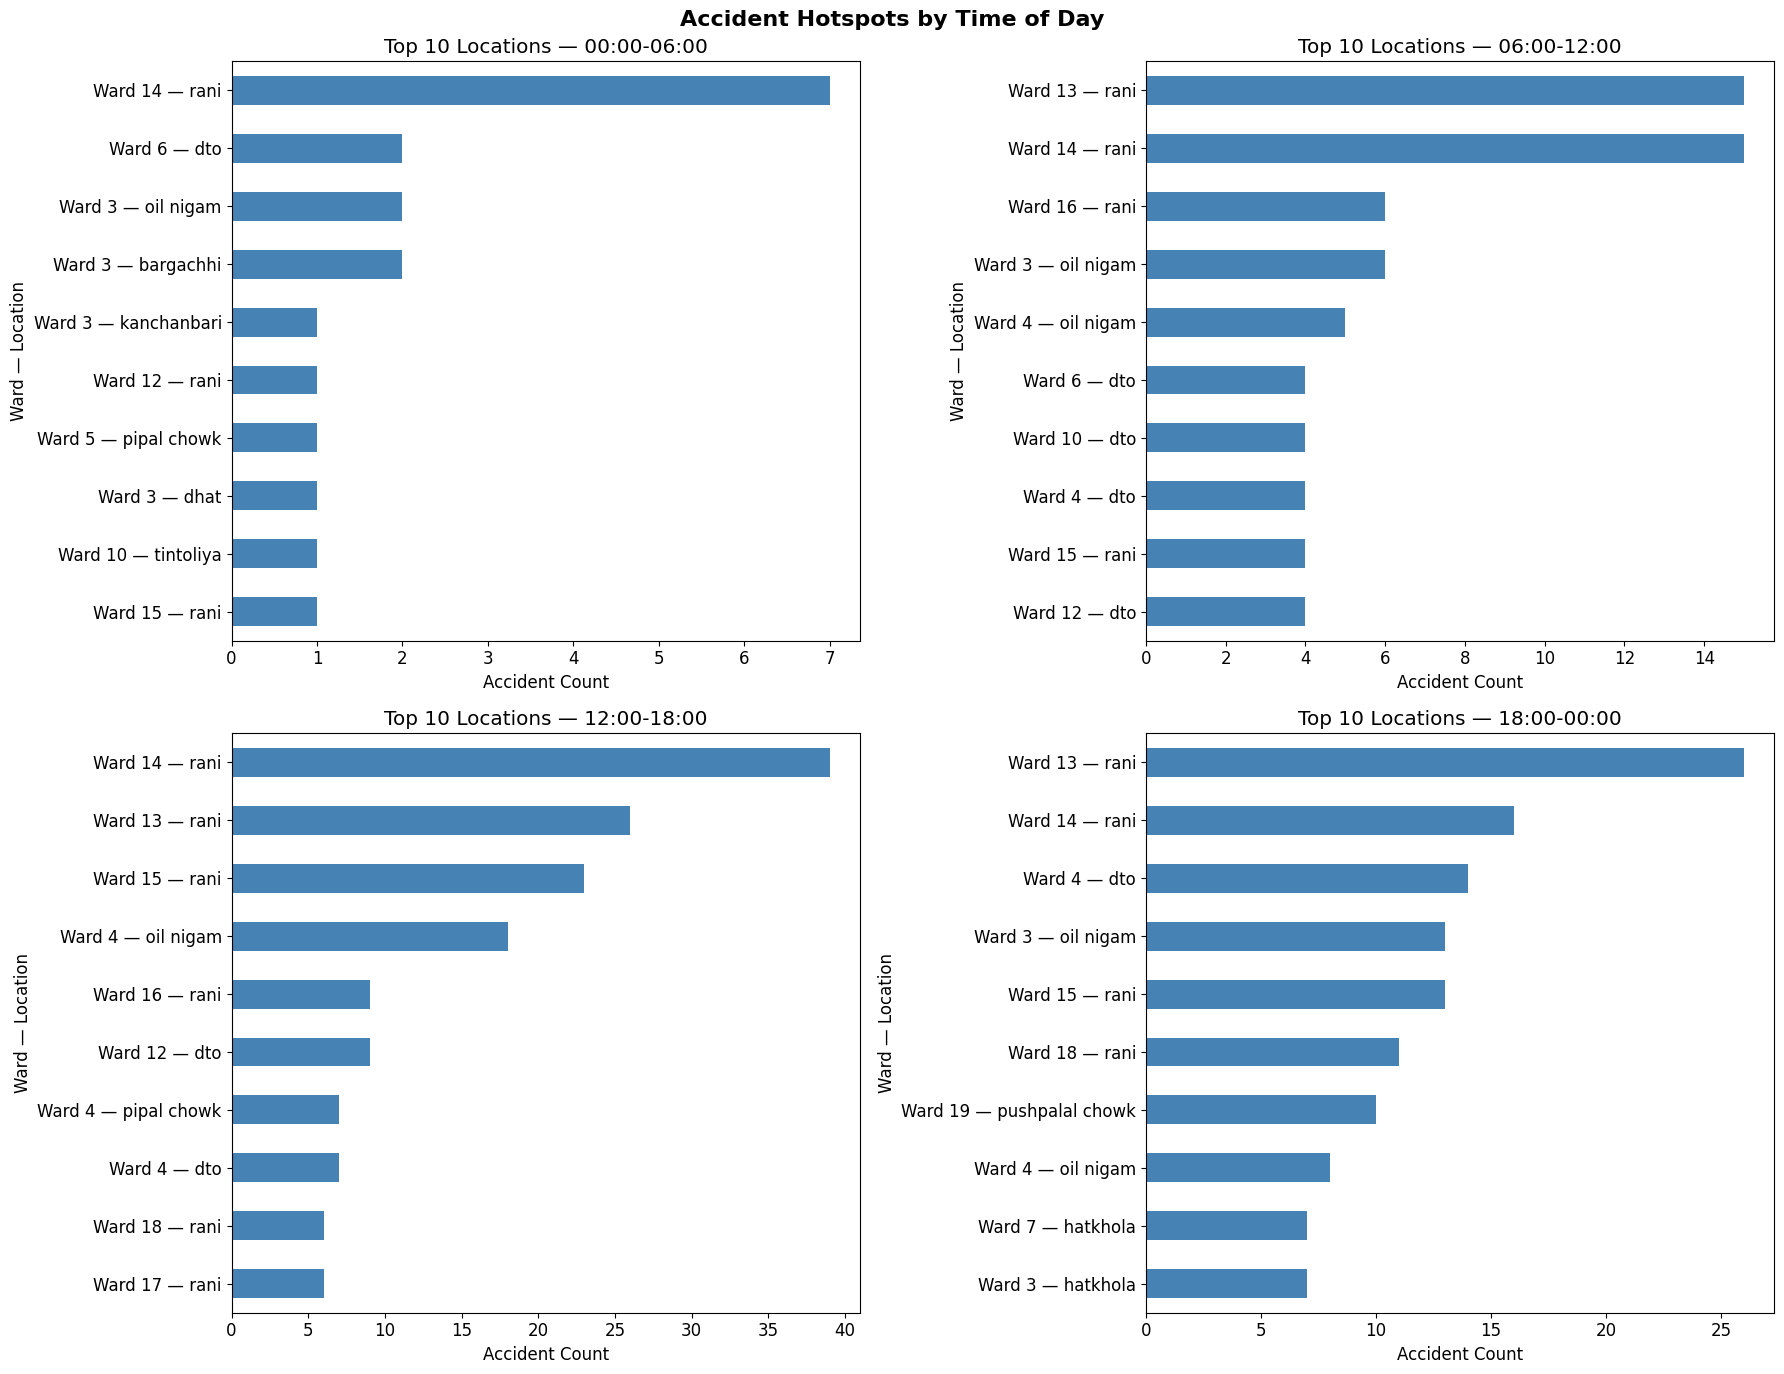

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for ax, time_slot in zip(axes.flatten(), time_order):
    data = df_eda[df_eda['Time_Range'] == time_slot]
    counts = data['Ward_Location'].value_counts().head(10)
    
    counts.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 10 Locations — {time_slot}')
    ax.set_xlabel('Accident Count')
    ax.set_ylabel('Ward — Location')
    ax.invert_yaxis()

plt.suptitle('Accident Hotspots by Time of Day', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

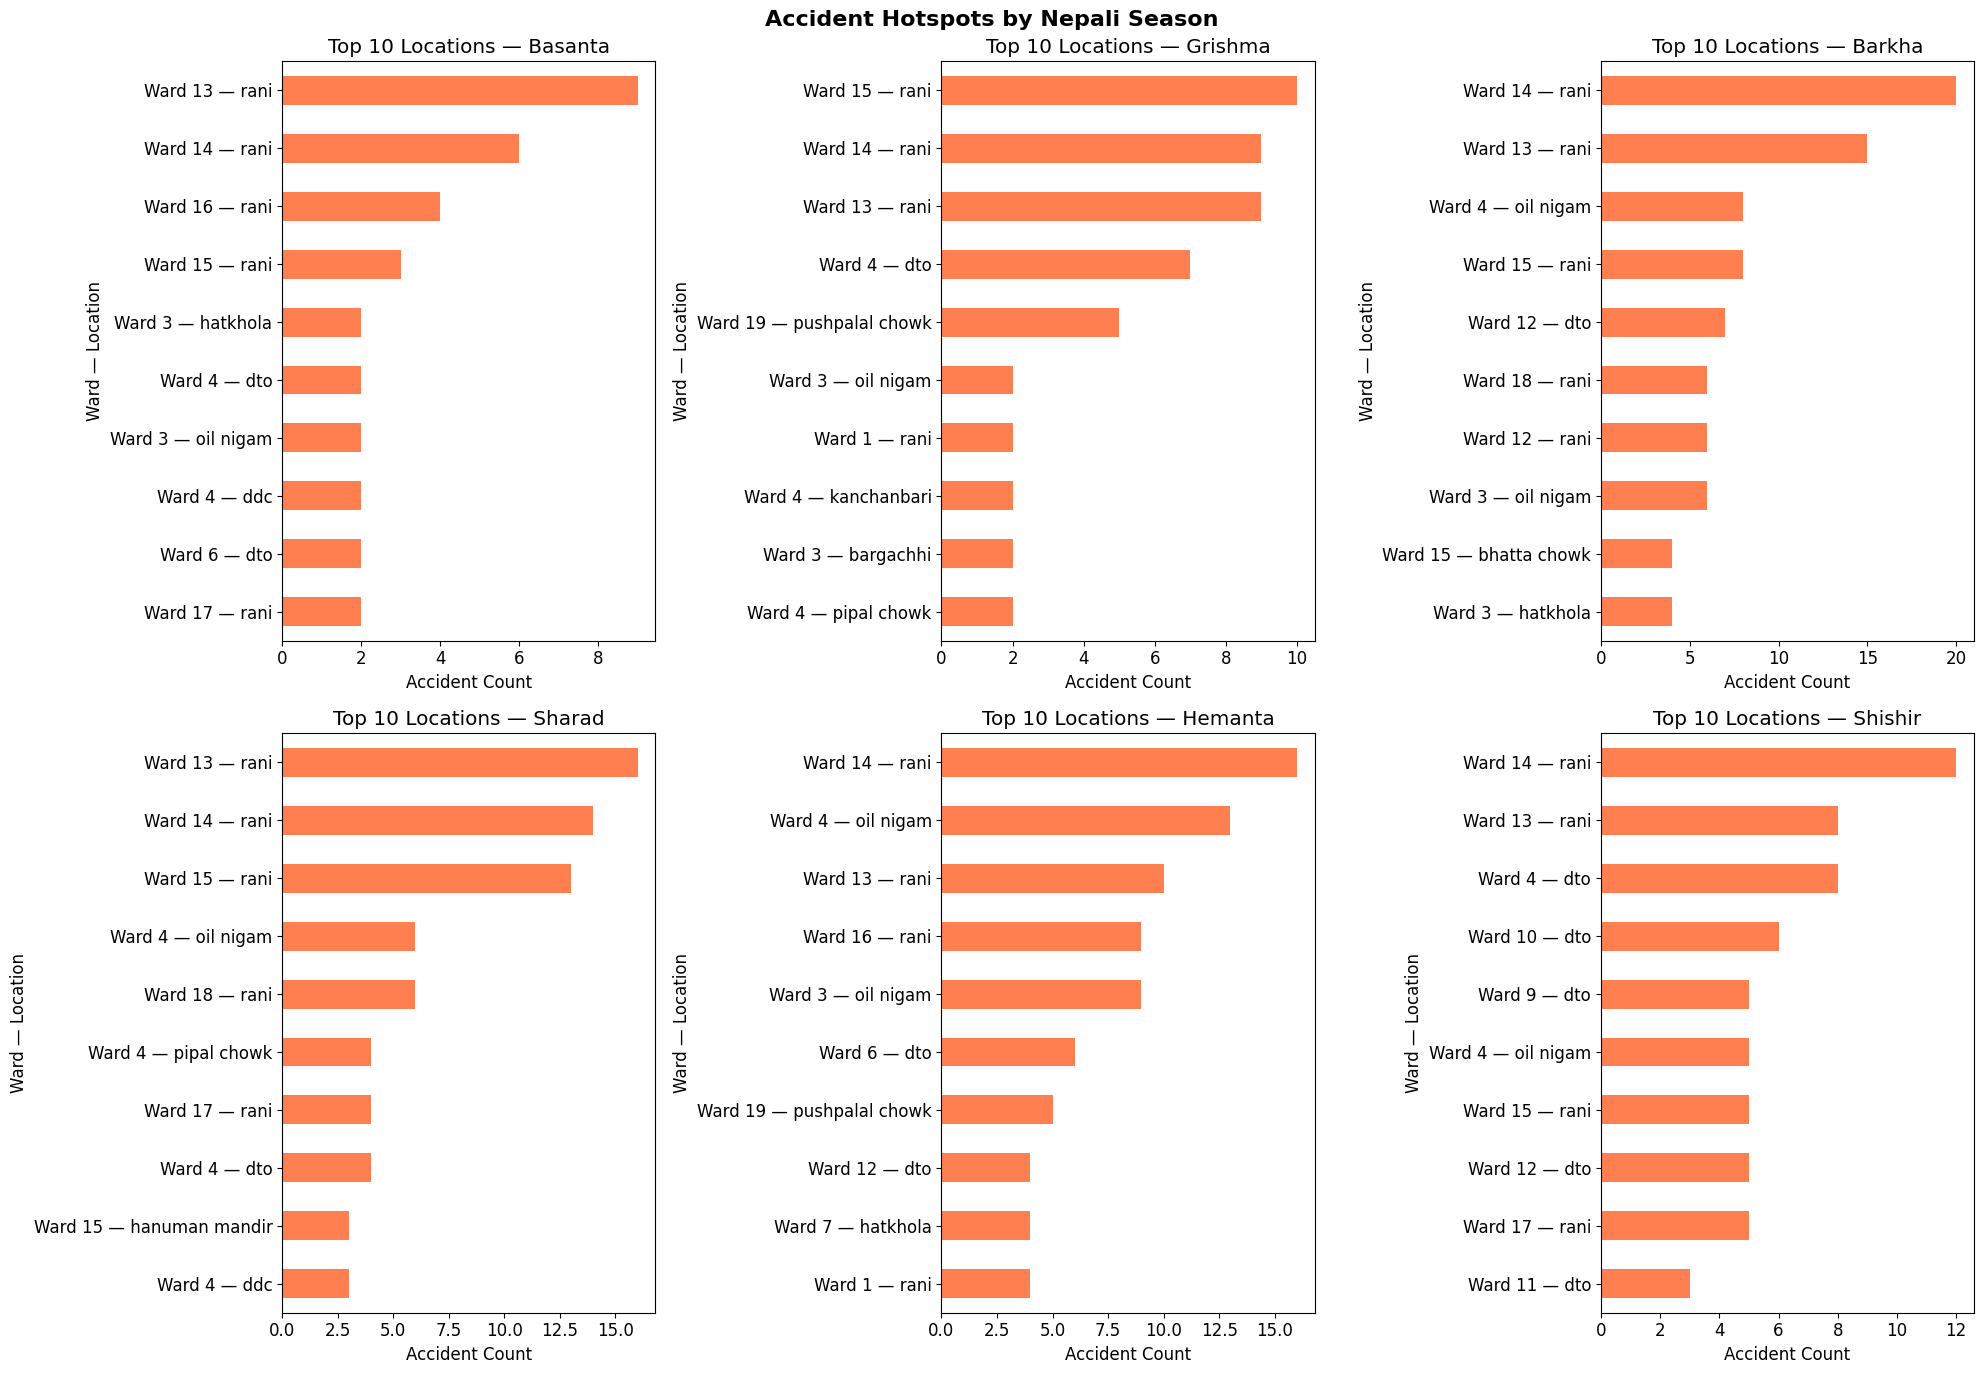

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(20, 14))

for ax, season in zip(axes.flatten(), nepali_season_order):
    data = df_eda[df_eda['Nepali_Season'] == season]
    counts = data['Ward_Location'].value_counts().head(10)
    
    counts.plot(kind='barh', ax=ax, color='coral')
    ax.set_title(f'Top 10 Locations — {season}')
    ax.set_xlabel('Accident Count')
    ax.set_ylabel('Ward — Location')
    ax.invert_yaxis()

plt.suptitle('Accident Hotspots by Nepali Season', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Sample Active Weathers:
Active_Weathers
Foggy, Humid, Overcast, Rainy    210
Clear, Dry, Mild, Pleasant       202
Clear, Cool, Dry, Foggy          196
Cold, Dry, Foggy, Frosty         150
Dry, Hot, Humid, Thunderstorm     84
Dry, Dusty, Mild, Warm, Windy     70
Name: count, dtype: int64


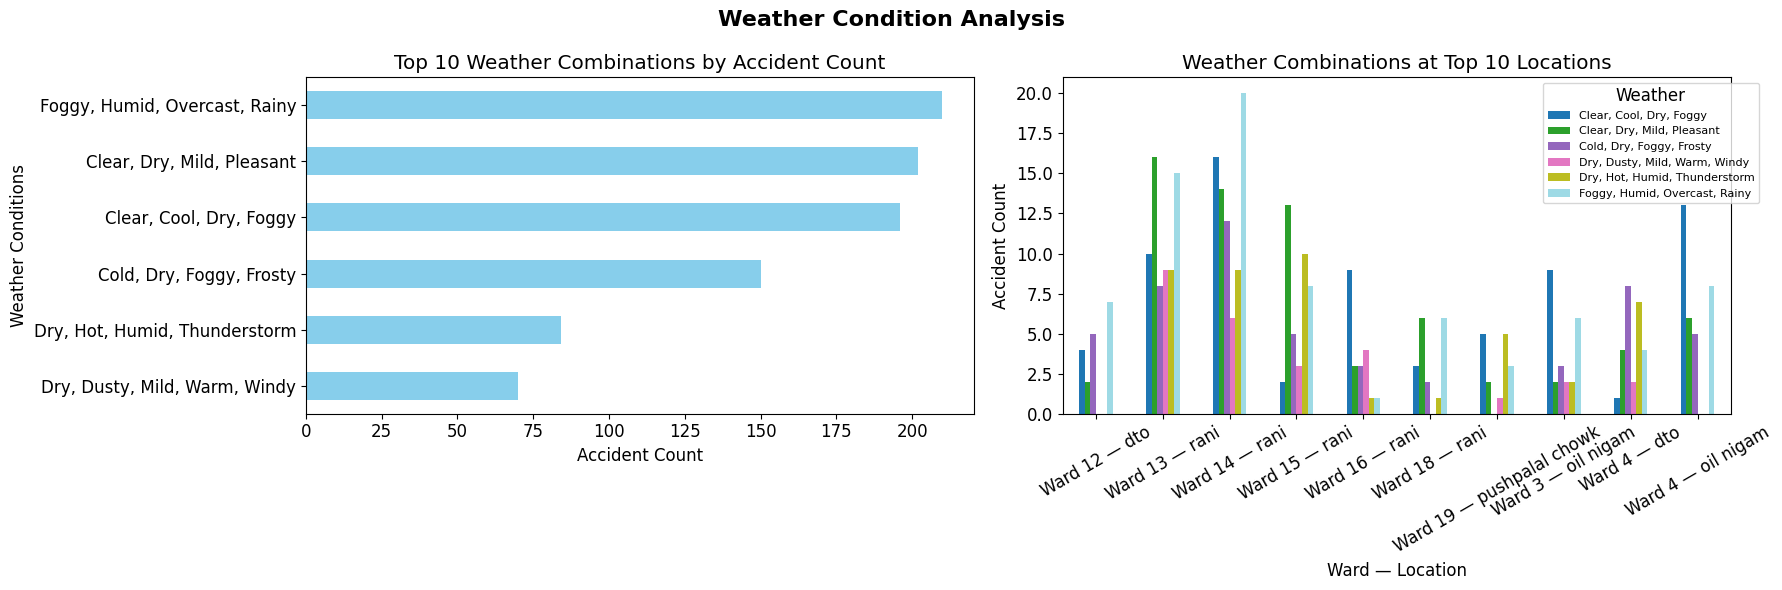

In [14]:
weather_cols = [col for col in df_eda.columns if col.startswith('Weather_')]

# Create Active_Weathers column
df_eda['Active_Weathers'] = df_eda[weather_cols].apply(
    lambda row: ', '.join([
        col.replace('Weather_', '')
        for col in weather_cols if row[col] == 1
    ]), axis=1
)
df_eda['Active_Weathers'] = df_eda['Active_Weathers'].replace('', 'Unknown')

print("Sample Active Weathers:")
print(df_eda['Active_Weathers'].value_counts().head(10))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top weather combinations by accident count
top_weather_combos = df_eda['Active_Weathers'].value_counts().head(10)
top_weather_combos.plot(kind='barh', ax=axes[0], color='skyblue')
axes[0].set_title('Top 10 Weather Combinations by Accident Count')
axes[0].set_xlabel('Accident Count')
axes[0].set_ylabel('Weather Conditions')
axes[0].invert_yaxis()

# Weather at top 10 locations
top10_locations = df_eda['Ward_Location'].value_counts().head(10).index
weather_loc = df_eda[df_eda['Ward_Location'].isin(top10_locations)]
weather_pivot = weather_loc.groupby(
    ['Ward_Location', 'Active_Weathers']
).size().unstack(fill_value=0)

weather_pivot.plot(kind='bar', ax=axes[1], colormap='tab20')
axes[1].set_title('Weather Combinations at Top 10 Locations')
axes[1].set_xlabel('Ward — Location')
axes[1].set_ylabel('Accident Count')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Weather', bbox_to_anchor=(1.05, 1), fontsize=8)

plt.suptitle('Weather Condition Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

=== Top 20 Most Dangerous Location + Season + Weather Combinations ===

     Ward_Location Nepali_Season               Active_Weathers Severity  Accident_Count
    Ward 14 — rani        Barkha Foggy, Humid, Overcast, Rainy      low              18
    Ward 13 — rani        Sharad    Clear, Dry, Mild, Pleasant      low              16
    Ward 14 — rani       Hemanta       Clear, Cool, Dry, Foggy      low              15
    Ward 13 — rani        Barkha Foggy, Humid, Overcast, Rainy      low              14
Ward 4 — oil nigam       Hemanta       Clear, Cool, Dry, Foggy      low              13
    Ward 14 — rani        Sharad    Clear, Dry, Mild, Pleasant      low              13
    Ward 14 — rani       Shishir      Cold, Dry, Foggy, Frosty      low              12
    Ward 15 — rani        Sharad    Clear, Dry, Mild, Pleasant      low              12
    Ward 15 — rani       Grishma Dry, Hot, Humid, Thunderstorm      low              10
    Ward 13 — rani       Hemanta       Clear, Co

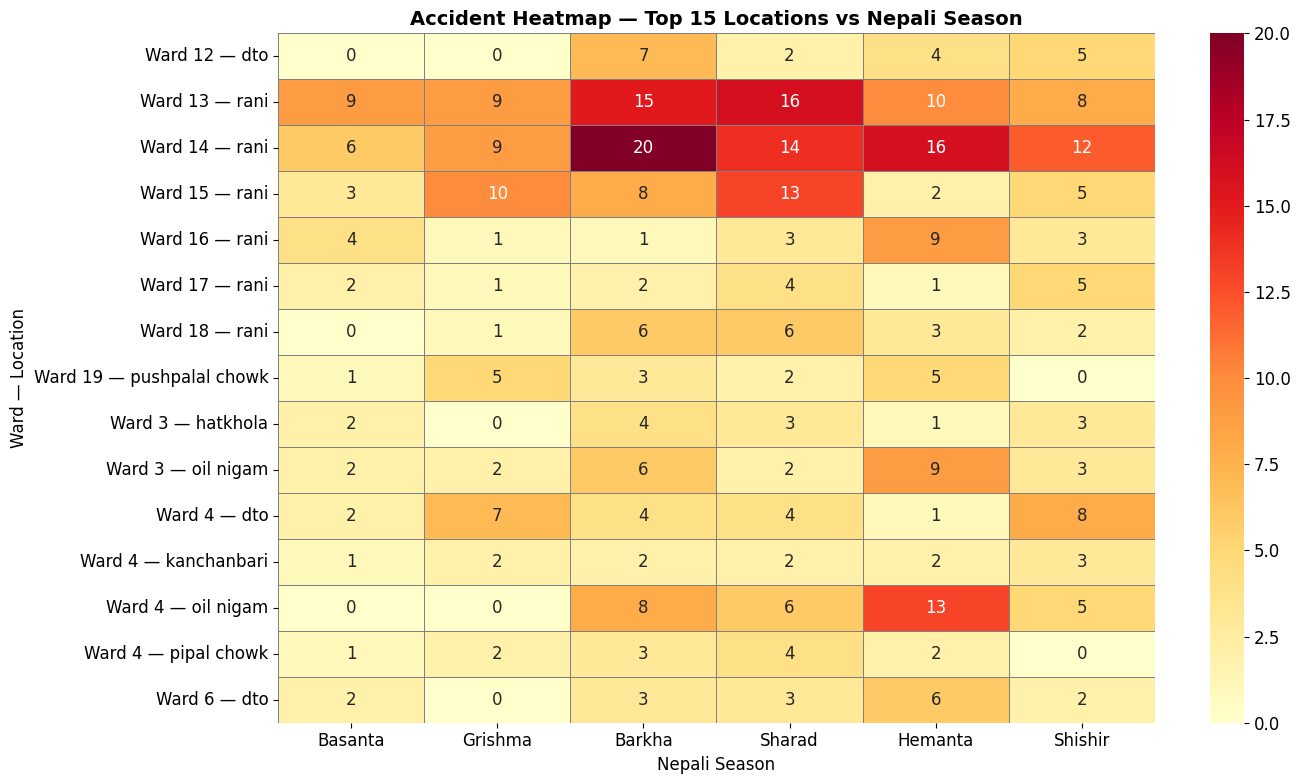

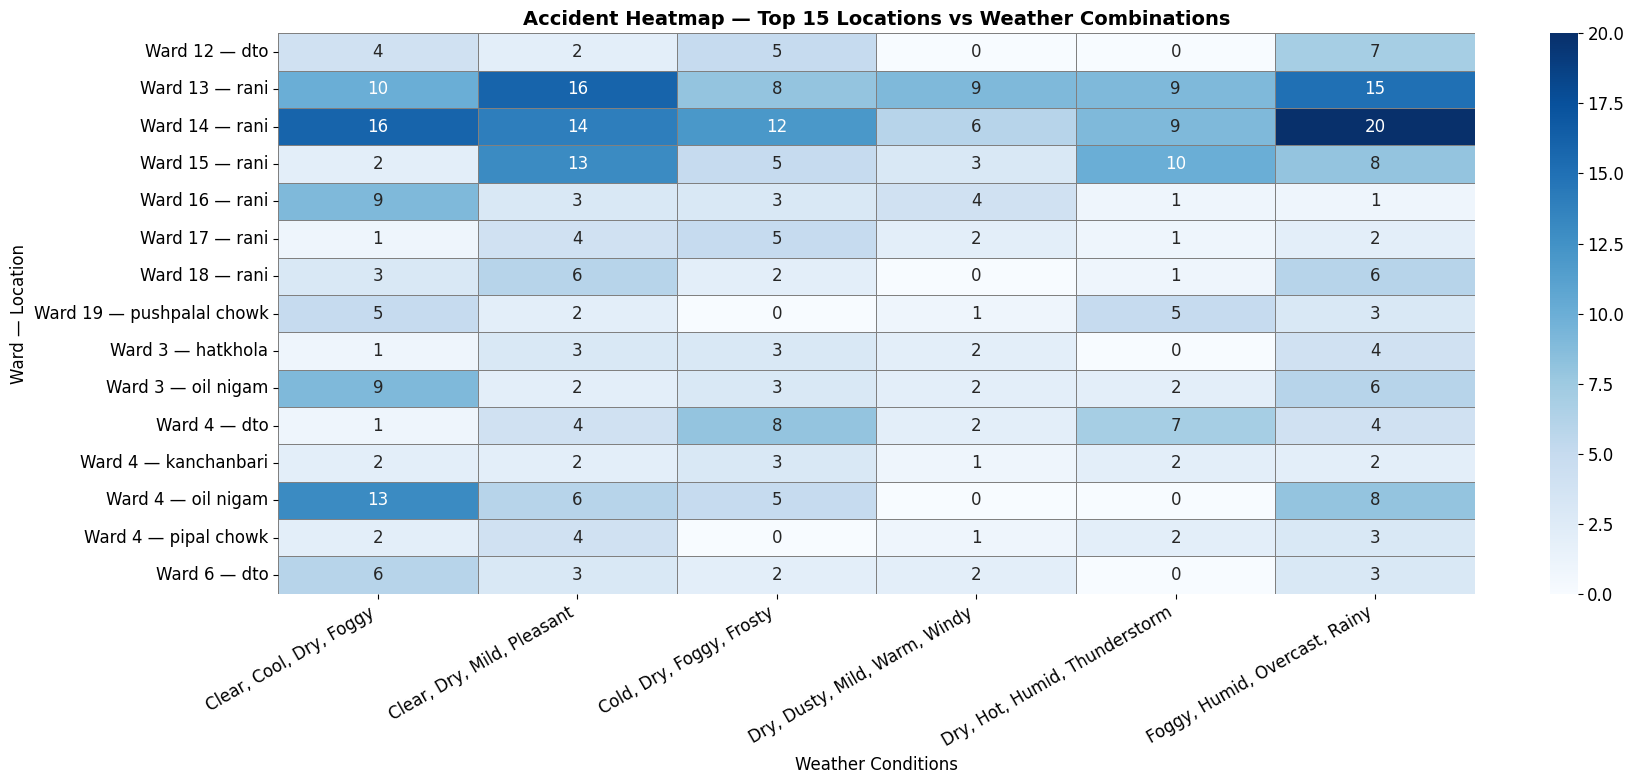

In [15]:
# Full combination table
spatio_temporal_weather = df_eda.groupby(
    ['Ward_Location', 'Nepali_Season', 'Active_Weathers', 'Severity']
).size().reset_index(name='Accident_Count')

top_combos = spatio_temporal_weather.sort_values(
    'Accident_Count', ascending=False
).head(20)

print("=== Top 20 Most Dangerous Location + Season + Weather Combinations ===\n")
print(top_combos.to_string(index=False))

# Heatmap 1 — Top 15 Locations vs Nepali Season
top15_locations = df_eda['Ward_Location'].value_counts().head(15).index

pivot_season = df_eda.groupby(
    ['Ward_Location', 'Nepali_Season']
).size().unstack(fill_value=0)
pivot_season = pivot_season.reindex(columns=nepali_season_order, fill_value=0)
pivot_season = pivot_season.loc[pivot_season.index.isin(top15_locations)]

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_season, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='gray')
plt.title('Accident Heatmap — Top 15 Locations vs Nepali Season',
          fontsize=14, fontweight='bold')
plt.xlabel('Nepali Season')
plt.ylabel('Ward — Location')
plt.tight_layout()
plt.show()

# Heatmap 2 — Top 15 Locations vs Weather
pivot_weather = df_eda.groupby(
    ['Ward_Location', 'Active_Weathers']
).size().unstack(fill_value=0)
pivot_weather = pivot_weather.loc[pivot_weather.index.isin(top15_locations)]

plt.figure(figsize=(18, 8))
sns.heatmap(pivot_weather, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, linecolor='gray')
plt.title('Accident Heatmap — Top 15 Locations vs Weather Combinations',
          fontsize=14, fontweight='bold')
plt.xlabel('Weather Conditions')
plt.ylabel('Ward — Location')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

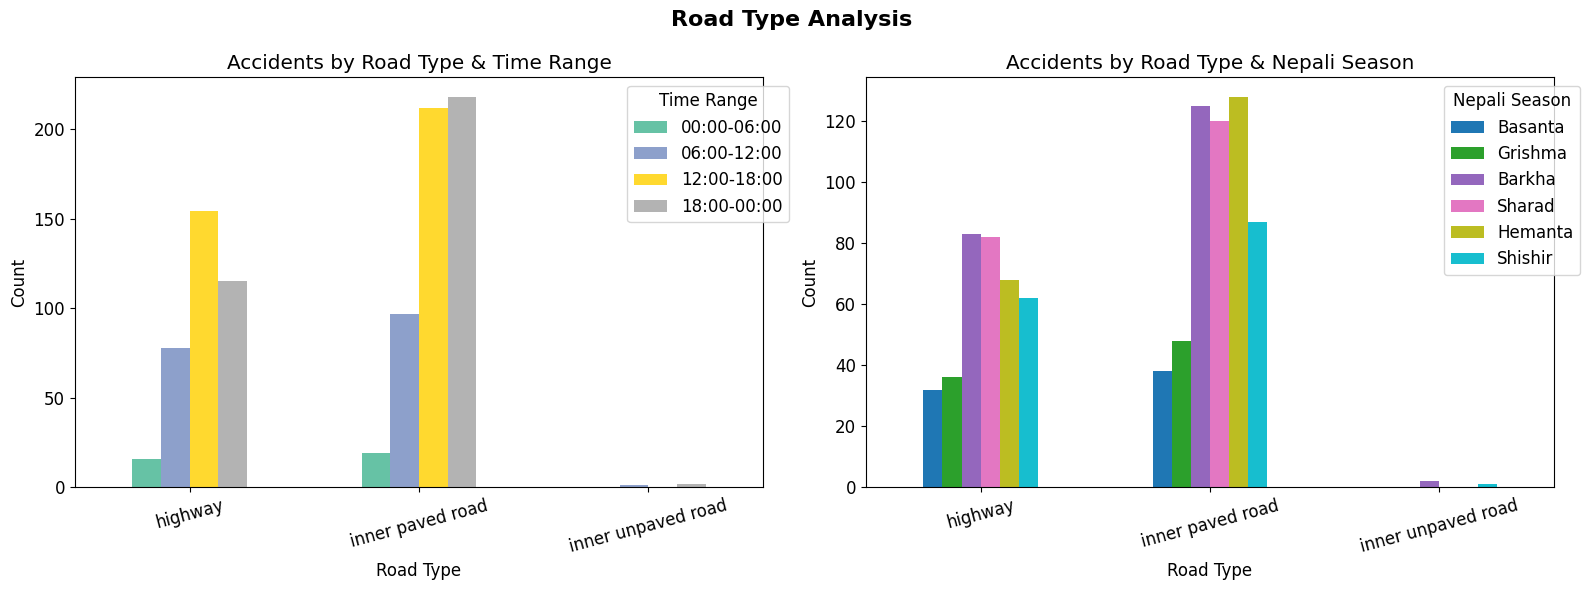

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Road type + Time Range
road_time = df_eda.groupby(['Road_Type', 'Time_Range']).size().unstack(fill_value=0)
road_time = road_time.reindex(columns=time_order, fill_value=0)
road_time.plot(kind='bar', ax=axes[0], colormap='Set2')
axes[0].set_title('Accidents by Road Type & Time Range')
axes[0].set_xlabel('Road Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(title='Time Range', bbox_to_anchor=(1.05, 1))

# Road type + Nepali Season
road_nepali = df_eda.groupby(['Road_Type', 'Nepali_Season']).size().unstack(fill_value=0)
road_nepali = road_nepali.reindex(columns=nepali_season_order, fill_value=0)
road_nepali.plot(kind='bar', ax=axes[1], colormap='tab10')
axes[1].set_title('Accidents by Road Type & Nepali Season')
axes[1].set_xlabel('Road Type')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Nepali Season', bbox_to_anchor=(1.05, 1))

plt.suptitle('Road Type Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
total_accidents = len(df_eda)

risk_freq = df_eda.groupby(
    ['Month', 'Month_Num', 'Nepali_Season', 'Ward',
     'Ward_Location', 'Time_Range', 'Active_Weathers']
).size().reset_index(name='Accident_Count')

risk_freq['Frequency_%'] = (
    risk_freq['Accident_Count'] / total_accidents * 100
).round(2)

risk_freq = risk_freq.sort_values(
    ['Accident_Count', 'Month_Num'], ascending=[False, True]
).reset_index(drop=True)

print("=== Historical Risk Frequency Table ===\n")
print(risk_freq.head(20).to_string(index=False))

print("\n=== Risk Summary (Top 10) ===\n")
for _, row in risk_freq.head(10).iterrows():
    print(
        f"At {row['Ward_Location']} during {row['Time_Range']} "
        f"in {row['Month']} ({row['Nepali_Season']} "
        f"- {row['Active_Weathers']}): "
        f"{row['Accident_Count']} accidents — "
        f"{row['Frequency_%']}% of all recorded accidents"
    )

=== Historical Risk Frequency Table ===

  Month  Month_Num Nepali_Season  Ward             Ward_Location  Time_Range               Active_Weathers  Accident_Count  Frequency_%
Shrawan          4        Barkha    14            Ward 14 — rani 12:00-18:00 Foggy, Humid, Overcast, Rainy               8         0.88
 Kartik          7        Sharad    13            Ward 13 — rani 12:00-18:00    Clear, Dry, Mild, Pleasant               6         0.66
  Poush          9       Hemanta     4        Ward 4 — oil nigam 12:00-18:00       Clear, Cool, Dry, Foggy               6         0.66
  Poush          9       Hemanta    14            Ward 14 — rani 12:00-18:00       Clear, Cool, Dry, Foggy               6         0.66
 Bhadra          5        Barkha    13            Ward 13 — rani 12:00-18:00 Foggy, Humid, Overcast, Rainy               5         0.55
 Kartik          7        Sharad    15            Ward 15 — rani 18:00-00:00    Clear, Dry, Mild, Pleasant               5         0.55
 Ashadh